<a href="https://colab.research.google.com/github/Vyshnavi262007/Assignment-3-AIML/blob/main/Customer_Segmentation_Using_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


In [3]:
# load uploaded file
df = pd.read_csv("/content/customer_segmentation_data.csv")

In [4]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   Customer ID  Age  Gender Marital Status    Education Level  \
0        84966   23  Female        Married   Associate Degree   
1        95568   26    Male        Widowed          Doctorate   
2        10544   29  Female         Single   Associate Degree   
3        77033   20    Male       Divorced  Bachelor's Degree   
4        88160   25  Female      Separated  Bachelor's Degree   

  Geographic Information    Occupation  Income Level Behavioral Data  \
0                Mizoram  Entrepreneur         70541         policy5   
1                    Goa       Manager         54168         policy5   
2              Rajasthan  Entrepreneur         73899         policy5   
3                 Sikkim  Entrepreneur         63381         policy5   
4            West Bengal       Manager         38794         policy1   

  Purchase History Interactions with Customer Service  \
0       04-10-2018                              Phone   
1       11-06-2018                              

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Customer ID                         53503 non-null  int64 
 1   Age                                 53503 non-null  int64 
 2   Gender                              53503 non-null  object
 3   Marital Status                      53503 non-null  object
 4   Education Level                     53503 non-null  object
 5   Geographic Information              53503 non-null  object
 6   Occupation                          53503 non-null  object
 7   Income Level                        53503 non-null  int64 
 8   Behavioral Data                     53503 non-null  object
 9   Purchase History                    53503 non-null  object
 10  Interactions with Customer Service  53503 non-null  object
 11  Insurance Products Owned            53503 non-null  ob

In [6]:
print("\nMissing values:")
print(df.isnull().sum())



Missing values:
Customer ID                           0
Age                                   0
Gender                                0
Marital Status                        0
Education Level                       0
Geographic Information                0
Occupation                            0
Income Level                          0
Behavioral Data                       0
Purchase History                      0
Interactions with Customer Service    0
Insurance Products Owned              0
Coverage Amount                       0
Premium Amount                        0
Policy Type                           0
Customer Preferences                  0
Preferred Communication Channel       0
Preferred Contact Time                0
Preferred Language                    0
Segmentation Group                    0
dtype: int64


In [7]:
# keep only numeric columns
df_num = df.select_dtypes(include=np.number).copy()

print("\nNumeric columns used:")
print(df_num.columns.tolist())

# remove rows with missing values if any
df_num = df_num.dropna()


Numeric columns used:
['Customer ID', 'Age', 'Income Level', 'Coverage Amount', 'Premium Amount']


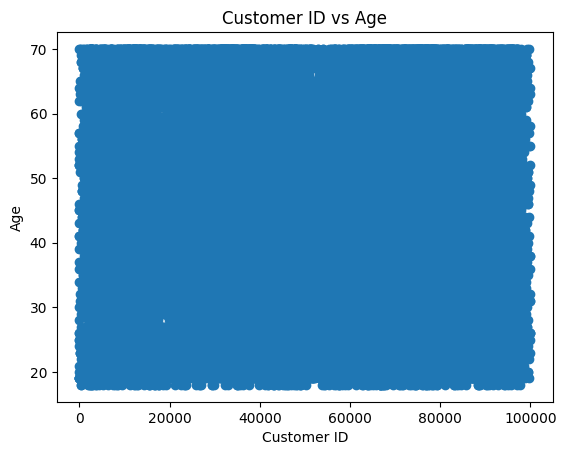

In [8]:
# visualization using first two numeric columns
if len(df_num.columns) >= 2:
    x_col = df_num.columns[0]
    y_col = df_num.columns[1]

    plt.scatter(df_num[x_col], df_num[y_col])
    plt.title(f"{x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()

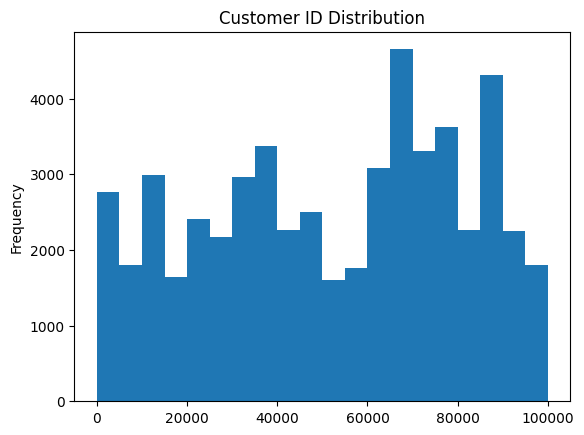

In [9]:
# histogram for first numeric column
df_num[df_num.columns[0]].plot(kind='hist', bins=20, title=f'{df_num.columns[0]} Distribution')
plt.show()


In [10]:
# scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_num)

print("\nScaled data:")
print(X_scaled[:5])


Scaled data:
[[0.8496585  0.09615385 0.38877521 0.33326561 0.49977778]
 [0.95567956 0.15384615 0.26282712 0.76866923 0.32577778]
 [0.10543105 0.21153846 0.41460638 0.76202712 0.86955556]
 [0.7703277  0.03846154 0.33369744 0.77664713 0.85377778]
 [0.88159882 0.13461538 0.14456376 0.33316351 0.17244444]]


In [11]:
# apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)


In [12]:
# add cluster labels
df_num['Cluster'] = clusters

print("\nData with clusters:")
print(df_num.head())


Data with clusters:
   Customer ID  Age  Income Level  Coverage Amount  Premium Amount  Cluster
0        84966   23         70541           366603            2749        1
1        95568   26         54168           780236            1966        2
2        10544   29         73899           773926            4413        1
3        77033   20         63381           787815            4342        1
4        88160   25         38794           366506            1276        2


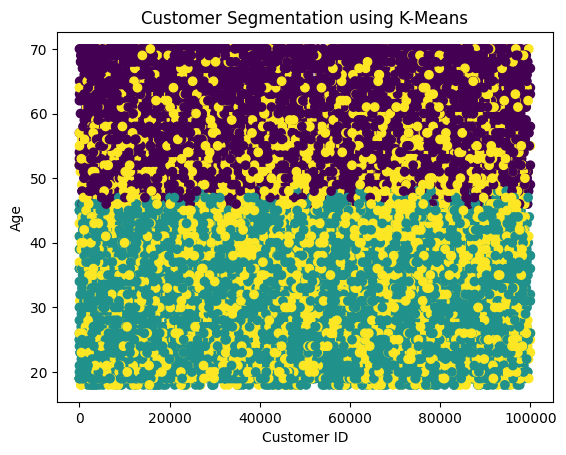

In [13]:
# cluster visualization
plt.scatter(df_num.iloc[:, 0], df_num.iloc[:, 1], c=df_num['Cluster'])
plt.title("Customer Segmentation using K-Means")
plt.xlabel(df_num.columns[0])
plt.ylabel(df_num.columns[1])
plt.show()

In [14]:
# clustering metrics
sil = silhouette_score(X_scaled, clusters)
ch = calinski_harabasz_score(X_scaled, clusters)
db = davies_bouldin_score(X_scaled, clusters)

print("\nSilhouette Score:", sil)
print("Calinski Harabasz Score:", ch)
print("Davies Bouldin Score:", db)


Silhouette Score: 0.15151228863338417
Calinski Harabasz Score: 9397.744913890101
Davies Bouldin Score: 1.9334203385154345
